# Berkeley Earth Global Temperature Anomalies: Time Series Analysis

This notebook analyzes monthly Berkeley Earth global land/ocean temperature anomalies from January 1850 through the latest observed month in the CSV. The goal is to answer three time-series questions:

1. Has the rate of warming changed over time?
2. Has the autocorrelation structure changed between the early and modern periods?
3. After removing the long-term trend, is there evidence of multi-year periodicity consistent with climate cycles such as ENSO?

The notebook is organized as a project workflow rather than a code walkthrough: data verification, exploratory diagnostics, trend modeling, residual dependence, spectral analysis, and forecasting/model comparison.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import signal, stats

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.structural import UnobservedComponents
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (11, 4.5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / 'Berk.comb.long.csv'
FIG_DIR = PROJECT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

## 1. Data Cleaning and Verification

The raw CSV includes future placeholder rows with value -9999. These are not observed temperatures, so they are removed before analysis. After cleaning, the dataset should be a monthly series with no missing months.

In [2]:
raw = pd.read_csv(DATA_PATH, skiprows=1, names=['date', 'anomaly'])
raw['date'] = pd.to_datetime(raw['date'])
raw['anomaly'] = pd.to_numeric(raw['anomaly'], errors='coerce')

# Berkeley/NOAA file uses large negative placeholders for unfilled future months.
df = raw.loc[raw['anomaly'] > -99].copy().reset_index(drop=True)
df = df.set_index('date').asfreq('MS')

print(f'Raw rows: {len(raw):,}')
print(f'Clean rows: {len(df):,}')
print(f'Date range: {df.index.min().date()} to {df.index.max().date()}')
print(f"Missing values after monthly reindexing: {df['anomaly'].isna().sum()}")
display(df.describe())

annual = df['anomaly'].resample('YS').mean().to_frame('anomaly')
annual['year'] = annual.index.year

Raw rows: 2,124
Clean rows: 2,114
Date range: 1850-01-01 to 2026-02-01
Missing values after monthly reindexing: 0


,anomaly
count,2114.000000
mean,0.032960
std,0.411558
min,-0.804000
25%,-0.252000
50%,-0.065500
75%,0.223000
max,1.481000


## 2. Initial Visualization

The full series shows a non-stationary mean: the average anomaly changes over time. The annual mean is plotted on top of the monthly data to make the long-run pattern easier to see.

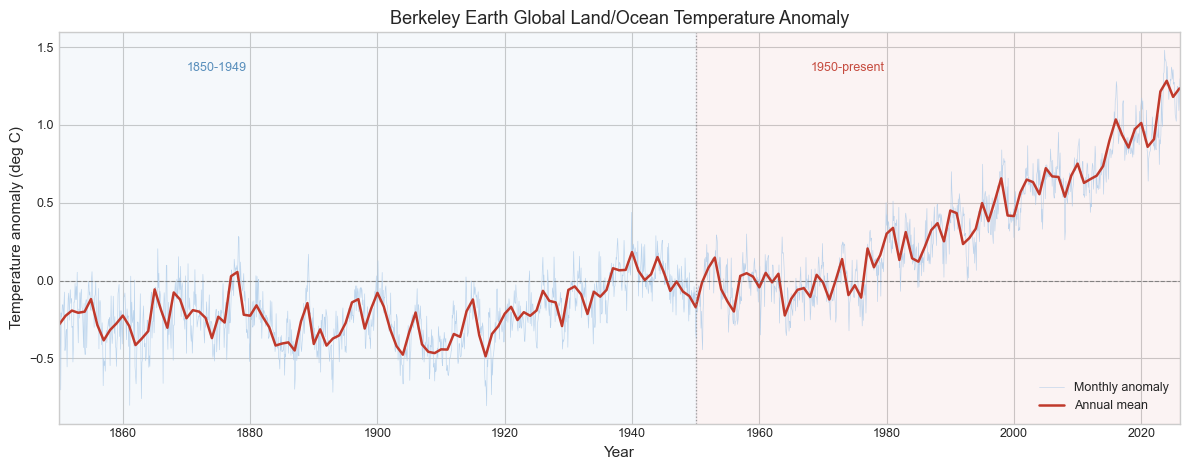

In [3]:
fig, ax = plt.subplots(figsize=(12, 4.8))

ax.plot(df.index, df['anomaly'], color='#a8c8e8', linewidth=0.45, alpha=0.75, label='Monthly anomaly')
ax.plot(annual.index, annual['anomaly'], color='#c0392b', linewidth=1.8, label='Annual mean')

ax.axhline(0, color='#555', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axvspan(df.index.min(), pd.Timestamp('1950-01-01'), alpha=0.05, color='steelblue')
ax.axvspan(pd.Timestamp('1950-01-01'), df.index.max(), alpha=0.05, color='firebrick')
ax.axvline(pd.Timestamp('1950-01-01'), color='#888', linewidth=0.9, linestyle=':', alpha=0.8)
ax.text(pd.Timestamp('1870-01-01'), 1.35, '1850-1949', fontsize=9, color='steelblue', alpha=0.9)
ax.text(pd.Timestamp('1968-01-01'), 1.35, '1950-present', fontsize=9, color='#c0392b', alpha=0.9)

ax.set_title('Berkeley Earth Global Land/Ocean Temperature Anomaly')
ax.set_xlabel('Year')
ax.set_ylabel('Temperature anomaly (deg C)')
ax.set_xlim(df.index.min(), df.index.max())
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax.legend(loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.savefig(FIG_DIR / '01_full_series.png', dpi=180, bbox_inches='tight')
plt.show()

## 3. Rolling Mean and Rolling Variability

Rolling summaries help separate long-run warming from short-run variability. A 10-year rolling mean shows slow changes in the average anomaly, while the rolling standard deviation shows whether variability changes over time.

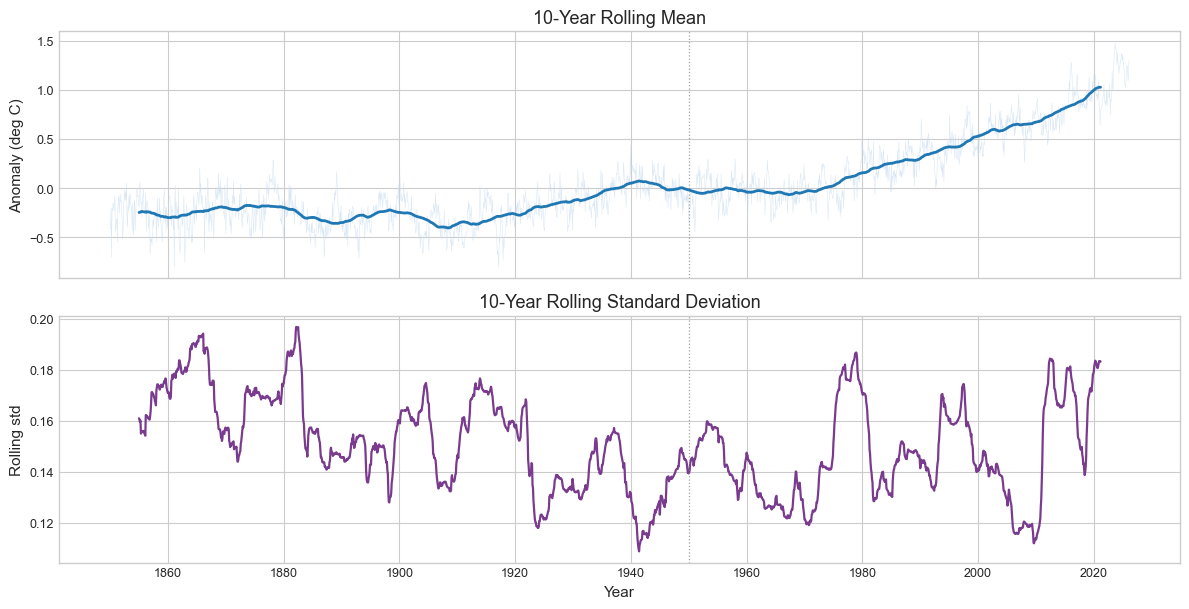

In [4]:
rolling = pd.DataFrame({
    '10-year rolling mean': df['anomaly'].rolling(120, center=True).mean(),
    '10-year rolling std': df['anomaly'].rolling(120, center=True).std(),
})

fig, axes = plt.subplots(2, 1, figsize=(12, 6.2), sharex=True)
axes[0].plot(df.index, df['anomaly'], color='#c7dcef', linewidth=0.35, alpha=0.7)
axes[0].plot(rolling.index, rolling['10-year rolling mean'], color='#1f77b4', linewidth=2)
axes[0].set_ylabel('Anomaly (deg C)')
axes[0].set_title('10-Year Rolling Mean')

axes[1].plot(rolling.index, rolling['10-year rolling std'], color='#7a3b8f', linewidth=1.6)
axes[1].set_ylabel('Rolling std')
axes[1].set_xlabel('Year')
axes[1].set_title('10-Year Rolling Standard Deviation')

for ax in axes:
    ax.axvline(pd.Timestamp('1950-01-01'), color='#888', linewidth=0.9, linestyle=':', alpha=0.8)

plt.tight_layout()
plt.savefig(FIG_DIR / '02_rolling_summaries.png', dpi=180, bbox_inches='tight')
plt.show()

## 4. Trend Modeling: Has the Warming Rate Changed?

A simple way to study changing warming rates is to fit linear trends to different eras. The slope is reported in degrees Celsius per decade so the results are interpretable.

,period,start,end,slope_degC_per_decade,stderr_per_decade,r_squared,p_value
0,Full record,1850-01-01,2026-02-01,0.064907,0.001051,0.643573,0.000000e+00
1,1850-1949,1850-01-01,1949-12-01,0.022344,0.001824,0.111278,1.404389e-32
2,1950-present,1950-01-01,2026-02-01,0.163413,0.002574,0.815491,0.000000e+00
3,1980-present,1980-01-01,2026-02-01,0.207425,0.004733,0.776752,7.095960e-182


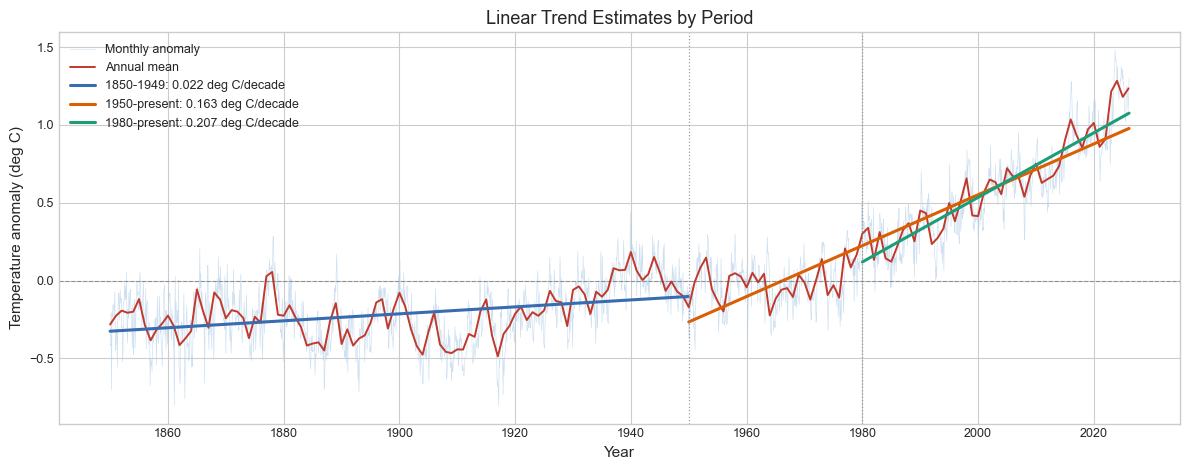

In [5]:
trend_df = df.copy()
trend_df['year_decimal'] = trend_df.index.year + (trend_df.index.month - 1) / 12
trend_df['post_1950'] = (trend_df.index >= '1950-01-01').astype(int)
trend_df['post_1980'] = (trend_df.index >= '1980-01-01').astype(int)

def fit_linear_trend(data, label):
    x = data['year_decimal'].to_numpy()
    y = data['anomaly'].to_numpy()
    slope, intercept, r_value, p_value, stderr = stats.linregress(x, y)
    return {
        'period': label,
        'start': data.index.min().date(),
        'end': data.index.max().date(),
        'slope_degC_per_decade': slope * 10,
        'stderr_per_decade': stderr * 10,
        'r_squared': r_value**2,
        'p_value': p_value,
        'intercept': intercept,
        'slope': slope,
    }

periods = {
    'Full record': trend_df,
    '1850-1949': trend_df.loc[:'1949-12-01'],
    '1950-present': trend_df.loc['1950-01-01':],
    '1980-present': trend_df.loc['1980-01-01':],
}

trend_results = pd.DataFrame([fit_linear_trend(data, label) for label, data in periods.items()])
display(trend_results[['period', 'start', 'end', 'slope_degC_per_decade', 'stderr_per_decade', 'r_squared', 'p_value']])

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(df.index, df['anomaly'], color='#b8d2ea', linewidth=0.45, alpha=0.7, label='Monthly anomaly')
ax.plot(annual.index, annual['anomaly'], color='#c0392b', linewidth=1.4, label='Annual mean')

colors = {'1850-1949': '#386cb0', '1950-present': '#d95f02', '1980-present': '#1b9e77'}
for row in trend_results.loc[trend_results['period'].isin(colors)].itertuples():
    sub = periods[row.period]
    fitted = row.intercept + row.slope * sub['year_decimal']
    ax.plot(sub.index, fitted, color=colors[row.period], linewidth=2.2,
            label=f'{row.period}: {row.slope_degC_per_decade:.3f} deg C/decade')

ax.axhline(0, color='#555', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(pd.Timestamp('1950-01-01'), color='#888', linewidth=0.9, linestyle=':', alpha=0.8)
ax.axvline(pd.Timestamp('1980-01-01'), color='#888', linewidth=0.9, linestyle=':', alpha=0.8)
ax.set_title('Linear Trend Estimates by Period')
ax.set_xlabel('Year')
ax.set_ylabel('Temperature anomaly (deg C)')
ax.legend(loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.savefig(FIG_DIR / '03_trend_by_period.png', dpi=180, bbox_inches='tight')
plt.show()

### Interpretation Prompt

Use the slope table above to answer: is the modern warming rate larger than the early-record warming rate? The line plot gives a visual summary, but the slopes in degrees Celsius per decade are the main result for this question.

## 5. Stationarity and Autocorrelation Diagnostics

Because the raw series has a strong trend, the ACF of the original data will remain high for many lags. To study dependence beyond the trend, we compare the raw series, first differences, and residuals after detrending.

In [6]:
# Detrend using a full-record linear trend. Residuals are used for dependence and spectrum checks.
full = trend_results.loc[trend_results['period'] == 'Full record'].iloc[0]
trend_df['linear_fitted'] = full['intercept'] + full['slope'] * trend_df['year_decimal']
trend_df['linear_resid'] = trend_df['anomaly'] - trend_df['linear_fitted']
trend_df['diff_anomaly'] = trend_df['anomaly'].diff()

series_to_test = {
    'Raw anomaly': trend_df['anomaly'].dropna(),
    'First difference': trend_df['diff_anomaly'].dropna(),
    'Linear detrended residual': trend_df['linear_resid'].dropna(),
}

adf_rows = []
for name, s in series_to_test.items():
    stat, pvalue, usedlag, nobs, crit, icbest = adfuller(s)
    adf_rows.append({'series': name, 'ADF statistic': stat, 'p-value': pvalue, 'used lags': usedlag})

adf_table = pd.DataFrame(adf_rows)
display(adf_table)

,series,ADF statistic,p-value,used lags
0,Raw anomaly,-0.147737,9.444712e-01,23
1,First difference,-14.793330,2.154383e-27,22
2,Linear detrended residual,-2.440153,1.307228e-01,23


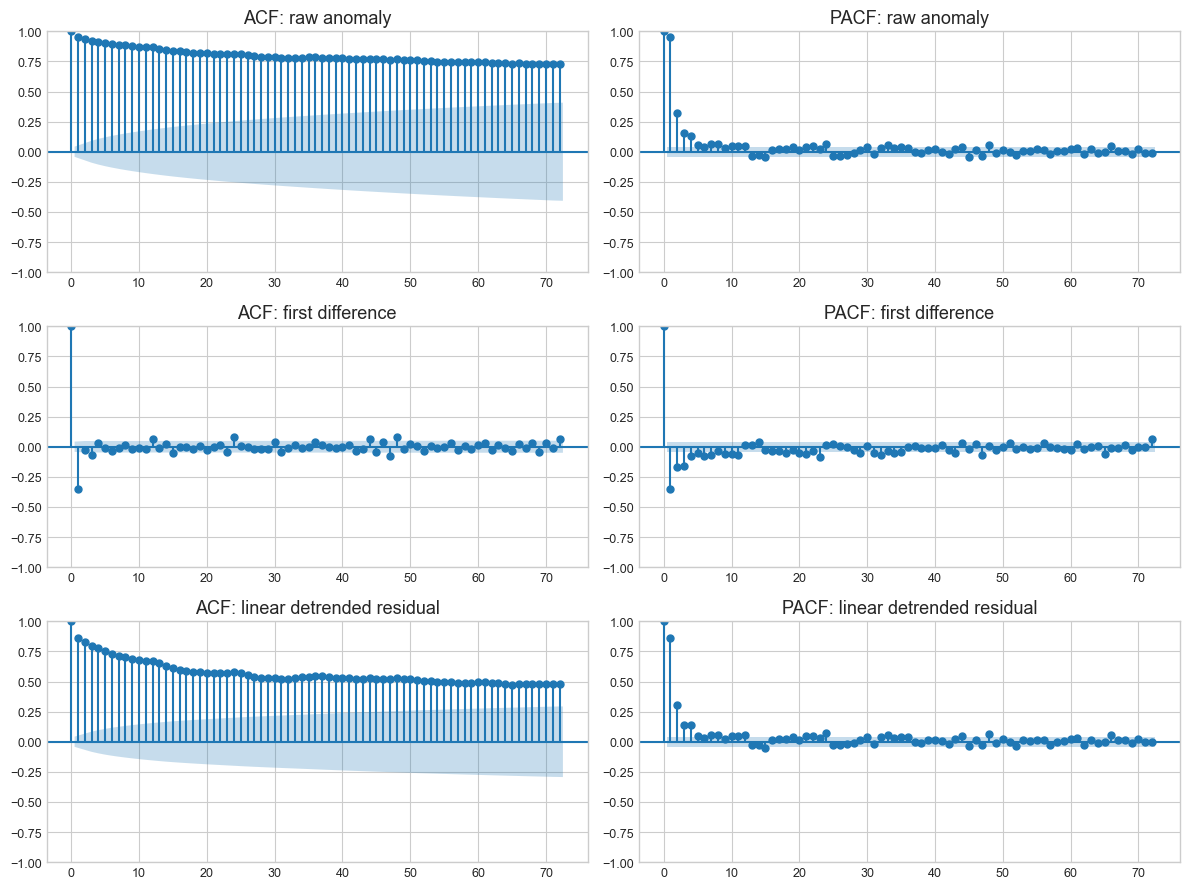

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(12, 9))

plot_acf(trend_df['anomaly'].dropna(), lags=72, ax=axes[0, 0], title='ACF: raw anomaly')
plot_pacf(trend_df['anomaly'].dropna(), lags=72, ax=axes[0, 1], title='PACF: raw anomaly', method='ywm')

plot_acf(trend_df['diff_anomaly'].dropna(), lags=72, ax=axes[1, 0], title='ACF: first difference')
plot_pacf(trend_df['diff_anomaly'].dropna(), lags=72, ax=axes[1, 1], title='PACF: first difference', method='ywm')

plot_acf(trend_df['linear_resid'].dropna(), lags=72, ax=axes[2, 0], title='ACF: linear detrended residual')
plot_pacf(trend_df['linear_resid'].dropna(), lags=72, ax=axes[2, 1], title='PACF: linear detrended residual', method='ywm')

plt.tight_layout()
plt.savefig(FIG_DIR / '04_acf_pacf_diagnostics.png', dpi=180, bbox_inches='tight')
plt.show()

## 6. Comparing Early and Modern Dependence

This section directly addresses whether the autocorrelation structure differs between 1850-1949 and 1950-present. The comparison is made on detrended residuals so that the result is less dominated by long-run warming.

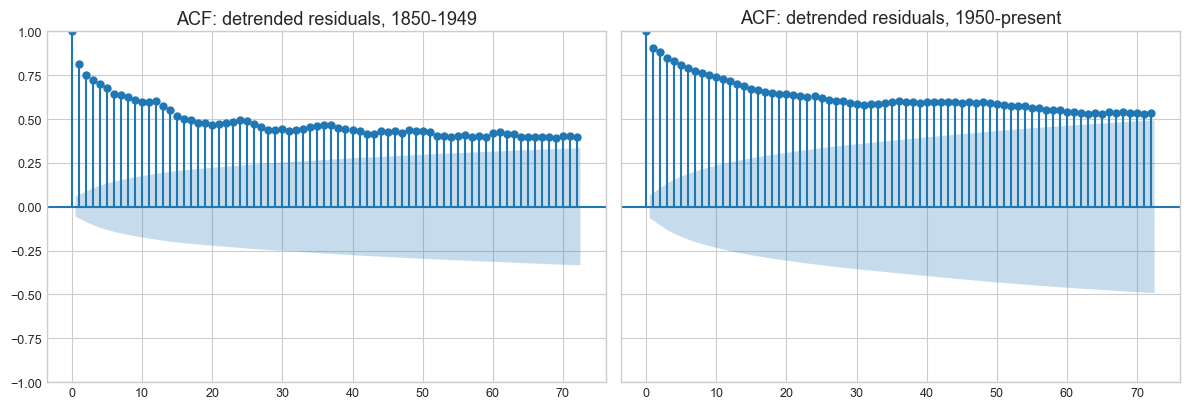

,period,lag_1_corr,lag_12_corr,lag_24_corr
0,1850-1949,0.814017,0.614227,0.512920
1,1950-present,0.911373,0.744283,0.694024


In [8]:
early = trend_df.loc[:'1949-12-01', 'linear_resid'].dropna()
modern = trend_df.loc['1950-01-01':, 'linear_resid'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
plot_acf(early, lags=72, ax=axes[0], title='ACF: detrended residuals, 1850-1949')
plot_acf(modern, lags=72, ax=axes[1], title='ACF: detrended residuals, 1950-present')
plt.tight_layout()
plt.savefig(FIG_DIR / '05_acf_early_vs_modern.png', dpi=180, bbox_inches='tight')
plt.show()

acf_summary = pd.DataFrame({
    'period': ['1850-1949', '1950-present'],
    'lag_1_corr': [early.autocorr(lag=1), modern.autocorr(lag=1)],
    'lag_12_corr': [early.autocorr(lag=12), modern.autocorr(lag=12)],
    'lag_24_corr': [early.autocorr(lag=24), modern.autocorr(lag=24)],
})
display(acf_summary)

## 7. Spectral Analysis: Multi-Year Periodicity

Welch's method estimates power by frequency. Here the input is detrended residuals, not the raw anomaly series, because the raw trend would dominate low frequencies. The x-axis is shown as period in years. The shaded band marks 2-7 year periods, the rough ENSO time scale.

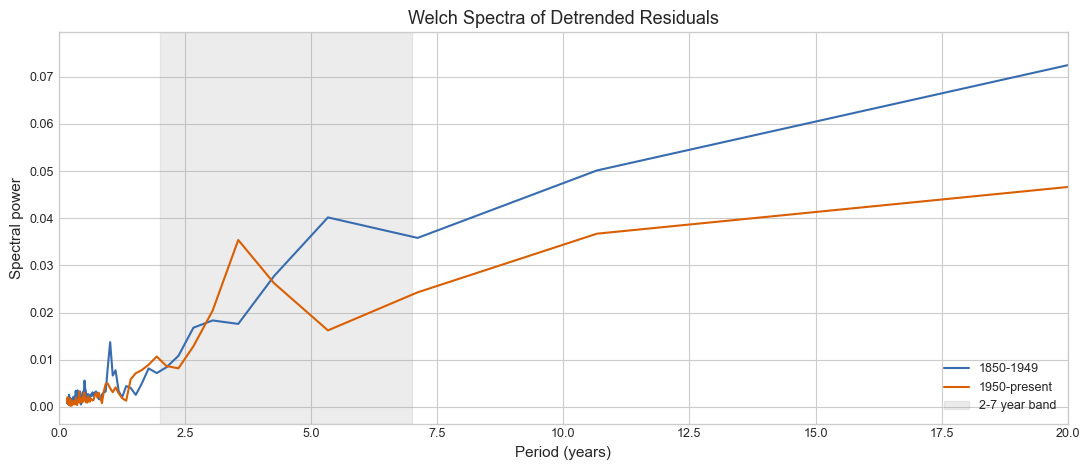

,period,mean_power_2_to_7_years
0,1850-1949,0.019998
1,1950-present,0.018287


In [9]:
def welch_periodogram_monthly(series, nperseg=256):
    values = series.dropna().to_numpy()
    freqs, power = signal.welch(values, fs=12, nperseg=min(nperseg, len(values)))
    mask = freqs > 0
    freqs = freqs[mask]
    power = power[mask]
    periods = 1 / freqs
    return pd.DataFrame({'frequency_cycles_per_year': freqs, 'period_years': periods, 'power': power})

spec_early = welch_periodogram_monthly(early)
spec_modern = welch_periodogram_monthly(modern)

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(spec_early['period_years'], spec_early['power'], color='#386cb0', linewidth=1.5, label='1850-1949')
ax.plot(spec_modern['period_years'], spec_modern['power'], color='#d95f02', linewidth=1.5, label='1950-present')
ax.axvspan(2, 7, color='#999999', alpha=0.18, label='2-7 year band')
ax.set_xlim(0, 20)
ax.set_xlabel('Period (years)')
ax.set_ylabel('Spectral power')
ax.set_title('Welch Spectra of Detrended Residuals')
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig(FIG_DIR / '06_welch_spectra.png', dpi=180, bbox_inches='tight')
plt.show()

# Average power in the ENSO-scale band.
def band_power(spec, low=2, high=7):
    band = spec.loc[(spec['period_years'] >= low) & (spec['period_years'] <= high)]
    return band['power'].mean()

spectral_summary = pd.DataFrame({
    'period': ['1850-1949', '1950-present'],
    'mean_power_2_to_7_years': [band_power(spec_early), band_power(spec_modern)],
})
display(spectral_summary)

## 8. Forecasting Models: ARIMA/SARIMA vs State Space Trend

The proposal includes SARIMA and a state space model. This section uses a held-out period beginning in 2015. The goal is not to build a climate forecasting system, but to compare whether a model with a time-varying trend is competitive with ARIMA-style specifications.

Because temperature anomaly data already removes much of the normal seasonal cycle, the seasonal SARIMA model below is intentionally modest. The non-seasonal ARIMA fit is included as a simpler baseline.

,model,RMSE,MAE,AIC_train,BIC_train
1,"SARIMA(1,1,1)(1,0,1)[12]",0.267447,0.212558,-2968.884594,-2935.385108
2,Local linear trend,0.280575,0.226314,-2887.835388,-2871.065864
0,"ARIMA(1,1,1)",0.282781,0.228316,-2933.679211,-2911.321868


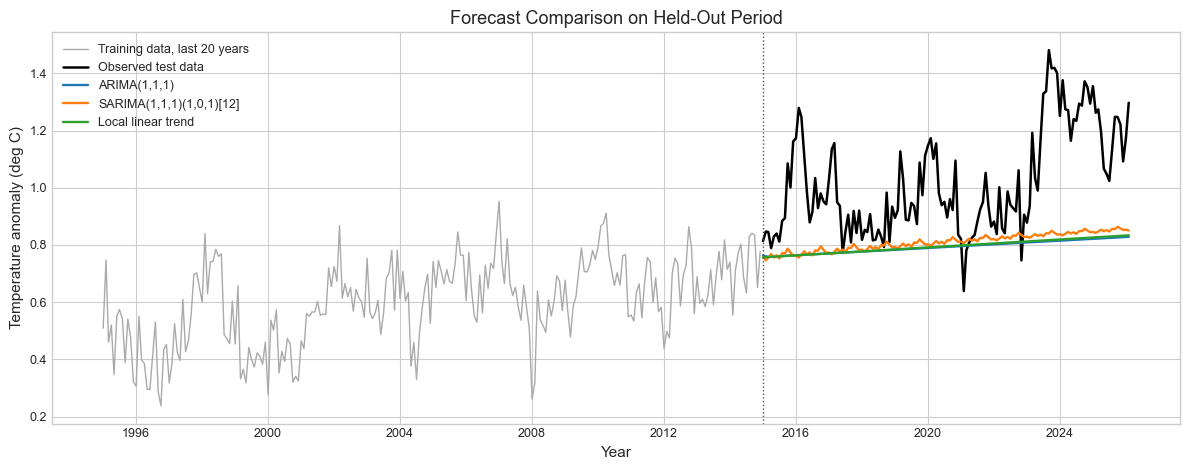

In [10]:
train = df.loc[:'2014-12-01', 'anomaly']
test = df.loc['2015-01-01':, 'anomaly']

models = {}
forecasts = pd.DataFrame(index=test.index)

# ARIMA with one difference and ARMA errors. This is a conservative baseline.
arima_model = SARIMAX(train, order=(1, 1, 1), trend='c', enforce_stationarity=False, enforce_invertibility=False)
arima_fit = arima_model.fit(disp=False)
forecasts['ARIMA(1,1,1)'] = arima_fit.get_forecast(steps=len(test)).predicted_mean
models['ARIMA(1,1,1)'] = arima_fit

# Modest SARIMA specification with annual seasonal ARMA terms.
sarima_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 0, 1, 12), trend='c', enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)
forecasts['SARIMA(1,1,1)(1,0,1)[12]'] = sarima_fit.get_forecast(steps=len(test)).predicted_mean
models['SARIMA(1,1,1)(1,0,1)[12]'] = sarima_fit

# Local linear trend state space model: level and slope can evolve through time.
lltrend_model = UnobservedComponents(train, level='local linear trend')
lltrend_fit = lltrend_model.fit(disp=False)
forecasts['Local linear trend'] = lltrend_fit.get_forecast(steps=len(test)).predicted_mean
models['Local linear trend'] = lltrend_fit

metrics = []
for name in forecasts.columns:
    rmse = np.sqrt(mean_squared_error(test, forecasts[name]))
    mae = mean_absolute_error(test, forecasts[name])
    metrics.append({'model': name, 'RMSE': rmse, 'MAE': mae, 'AIC_train': models[name].aic, 'BIC_train': models[name].bic})

metrics = pd.DataFrame(metrics).sort_values('RMSE')
display(metrics)

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(train.index[-240:], train.iloc[-240:], color='#aaaaaa', linewidth=1, label='Training data, last 20 years')
ax.plot(test.index, test, color='black', linewidth=1.8, label='Observed test data')
for name in forecasts.columns:
    ax.plot(forecasts.index, forecasts[name], linewidth=1.7, label=name)

ax.axvline(pd.Timestamp('2015-01-01'), color='#555', linestyle=':', linewidth=1)
ax.set_title('Forecast Comparison on Held-Out Period')
ax.set_xlabel('Year')
ax.set_ylabel('Temperature anomaly (deg C)')
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig(FIG_DIR / '07_forecast_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

## 9. Summary of Findings

- **Trend:** The estimated warming rate is much larger in the modern record than in the early record. The 1850-1949 slope is about 0.022 deg C per decade, compared with about 0.163 deg C per decade from 1950-present and about 0.207 deg C per decade from 1980-present. This supports the conclusion that the rate of warming has increased over time.
- **Autocorrelation:** After removing a full-record linear trend, the modern period has stronger residual autocorrelation than the early period. The lag-1 correlation rises from about 0.814 in 1850-1949 to about 0.911 in 1950-present; lag-12 rises from about 0.614 to 0.744; and lag-24 rises from about 0.513 to 0.694. This suggests greater persistence in modern residual variation.
- **Spectral analysis:** The 2-7 year band does not appear stronger in the modern period under the linear-detrended Welch analysis. Average power in that band is about 0.0200 for 1850-1949 and about 0.0183 for 1950-present, so the evidence for a stronger modern ENSO-scale signal is weak in this global aggregate series.
- **Forecasting:** On the 2015-2026 holdout, the seasonal SARIMA model has the lowest RMSE and MAE among the fitted models, followed by the local linear trend model and then the non-seasonal ARIMA baseline. The differences are modest, but including seasonal ARMA terms slightly improves forecast accuracy for this comparison.

## 10. Limitations and Next Steps

Important limitations:

- This is a single global aggregate series, so regional climate differences are not studied.
- Temperature anomalies already remove the typical seasonal temperature cycle, so any seasonal model should be justified by the diagnostics rather than assumed.
- ENSO is only indirectly assessed through residual periodicity. The spectral comparison is descriptive rather than a formal test of an ENSO mechanism; a stronger analysis would include a direct ENSO index.
- Early measurements may have greater uncertainty than recent measurements, but this notebook treats all observations equally.
- Statistical forecasts are useful for model comparison, but they are not a substitute for physical climate models.

Possible next steps:

- Add CO2, volcanic aerosol, solar, or ENSO covariates.
- Compare land-only, ocean-only, and regional temperature series.
- Use Berkeley Earth's uncertainty estimates if available.
- Fit richer state space models with covariates or stochastic cycles.